In [1]:
import pandas as pd
import numpy as np
import joblib

import shap
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("..")

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
(OUTPUT_PATH / "charts").mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [ ]:
np.load(PROCESSED_PATH / "X_train.npy")

np.load(PROCESSED_PATH / "X_test.npy")

np.load(PROCESSED_PATH / "y_train.npy")

np.load(PROCESSED_PATH / "y_test.npy")

In [ ]:
# Load our best-performing model (XGBoost)
joblib.load(MODEL_PATH / "xgboost_model.pkl")

In [ ]:
preprocessor = joblib.load(MODEL_PATH / "preprocessor.pkl")

In [6]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

print()

print("Model Loaded Successfully!")
print("Preprocessor Loaded Successfully!")

Training Features : (5634, 46)
Testing Features  : (1409, 46)

Training Labels : (5634,)
Testing Labels  : (1409,)

Model Loaded Successfully!
Preprocessor Loaded Successfully!


In [7]:
# Recover transformed feature names

feature_names = preprocessor.get_feature_names_out()

In [8]:
# Remove technical prefixes so plots are easier to read
feature_names = [

    feature.replace("categorical__", "")
           .replace("numerical__", "")

    for feature in feature_names

]

In [9]:
print("Total Features :", len(feature_names))

print()

print(feature_names[:10])

Total Features : 46

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Gender_Female', 'Gender_Male', 'Senior Citizen_No', 'Senior Citizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No']


In [10]:
# SHAP learns how our trained XGBoost model makes decisions. Later it will explain every prediction made by the model.

explainer = shap.TreeExplainer(xgboost_model)

print("SHAP Explainer created successfully!")

SHAP Explainer created successfully!


In [11]:
# Every customer receives an explanation showing
# how each feature influenced the prediction.

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [12]:
# SHAP returns one explanation per customer.

print("Type :", type(shap_values))
print()

print("Shape :", np.array(shap_values).shape)

Type : <class 'numpy.ndarray'>

Shape : (1409, 46)


In [13]:
customer_index = 0

print("Customer Index :", customer_index)
print()

print("First 10 SHAP values")

print(shap_values[customer_index][:10])

Customer Index : 0

First 10 SHAP values
[-1.2198207   0.12940975  0.1035962   0.06127426  0.00645351  0.01066376
  0.00379346  0.07076323  0.00420691  0.22803238]


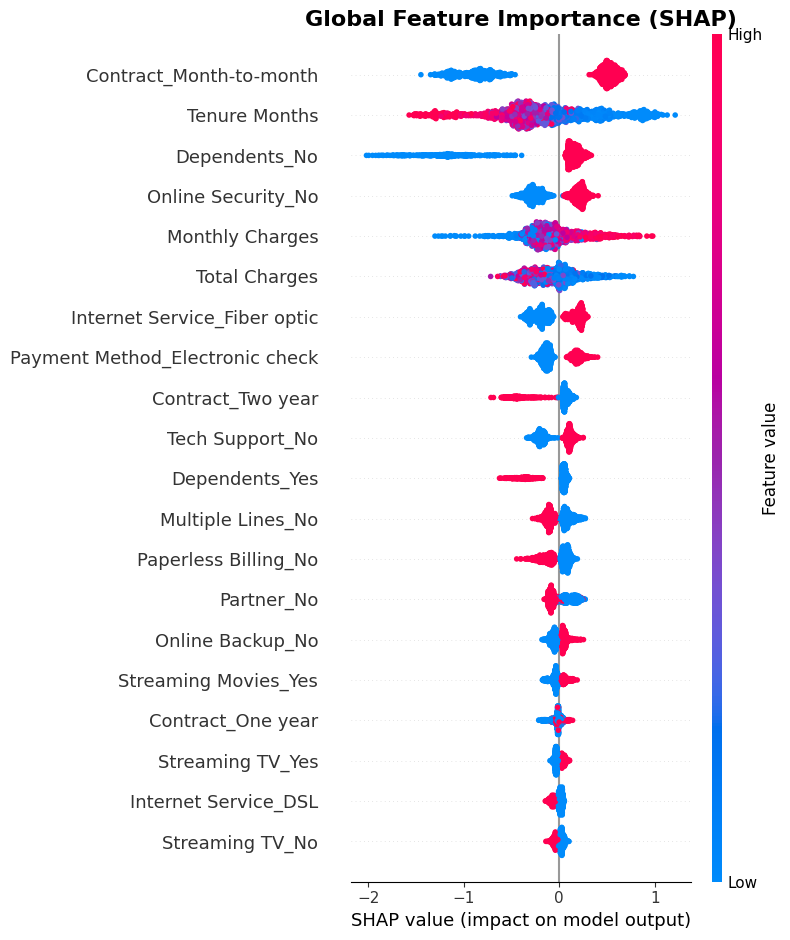

In [ ]:
# This plot explains the model globally. Every dot represents one customer.

plt.figure(figsize=(12,8))

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=feature_names,

    show=False

)

plt.title(
    "Global Feature Importance (SHAP)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()



plt.show()

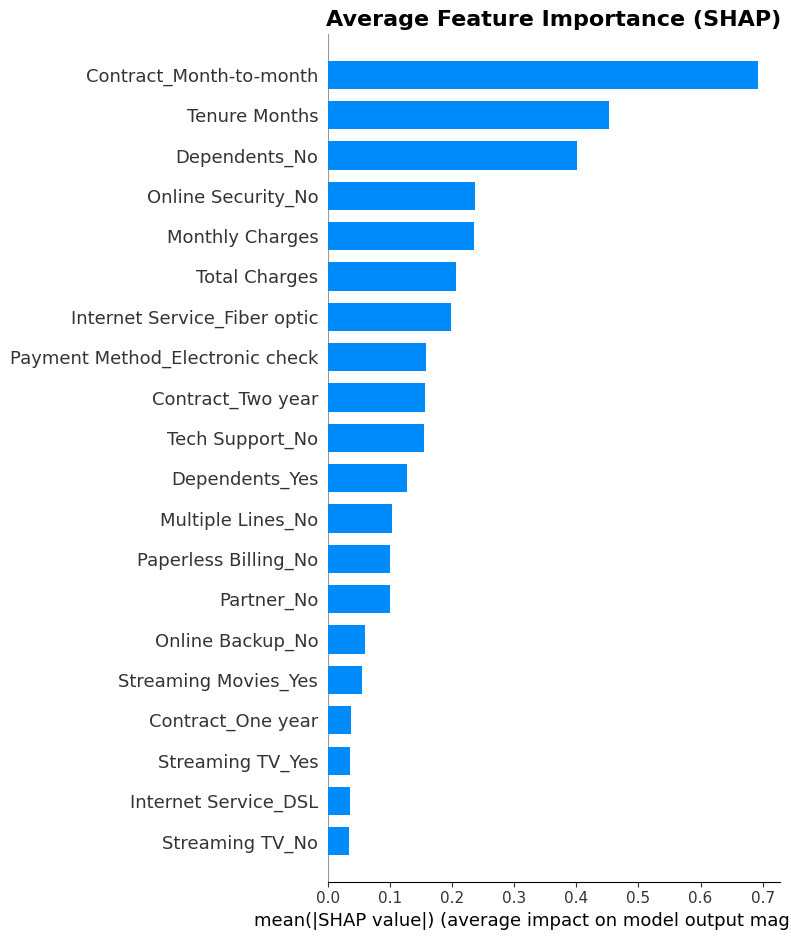

In [ ]:
# Mean SHAP Importance

plt.figure(figsize=(10,7))

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=feature_names,

    plot_type="bar",

    show=False

)

plt.title(
    "Average Feature Importance (SHAP)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()



plt.show()

In [16]:
# We'll explain the first customer in our testing dataset.

customer_index = 0

print("Customer Index:", customer_index)

Customer Index: 0


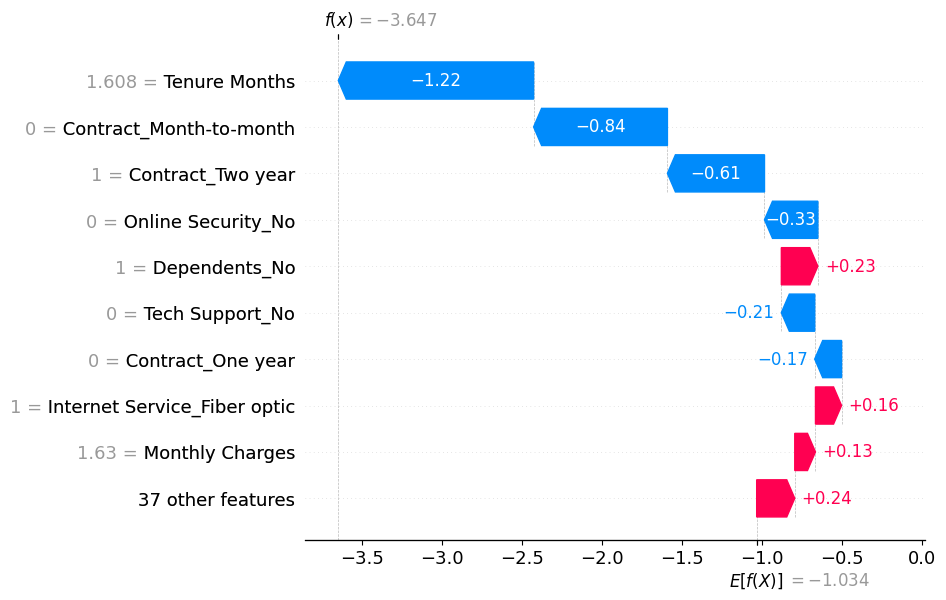

In [17]:
# Waterfall plots explain one prediction step-by-step.

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[customer_index],

        base_values=explainer.expected_value,

        data=X_test[customer_index],

        feature_names=feature_names

    ),

    max_display=10

)

In [23]:
# Convert SHAP values into a DataFrame

shap_df = pd.DataFrame(

    shap_values,

    columns=feature_names

)

print("SHAP DataFrame Shape :", shap_df.shape)

shap_df.head()

SHAP DataFrame Shape : (1409, 46)


,Tenure Months,Monthly Charges,Total Charges,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,-1.219821,0.129410,0.103596,0.061274,0.006454,0.010664,0.003793,0.070763,0.004207,0.228032,...,0.042684,-0.835884,-0.167695,-0.606384,0.032719,0.009474,-0.026779,0.028930,-0.106029,0.006859
1,0.446963,0.734592,0.324364,0.055610,0.020621,0.094840,0.003521,-0.082262,-0.015441,0.131214,...,0.100550,0.618718,-0.017358,0.099267,0.116025,0.009924,-0.004056,-0.004870,-0.088451,0.003795
2,-0.173214,-0.025570,0.089805,-0.022006,-0.011400,-0.000030,0.009600,0.187123,0.031685,0.209167,...,-0.106286,-0.843207,0.021536,0.093988,0.046342,0.018528,0.012894,-0.009716,-0.173197,0.014004
3,-0.150194,0.007814,-0.074746,-0.023986,-0.005398,0.022151,0.010368,0.243649,0.062441,0.165053,...,-0.017398,0.488076,-0.014065,0.072414,-0.236448,-0.037328,0.002876,0.006752,0.234560,0.011504
4,-1.467363,-0.253374,-0.238754,-0.034230,-0.004572,-0.030891,0.000854,0.145521,0.008345,0.184660,...,0.057445,-0.870334,-0.168084,-0.513752,0.034805,0.018934,-0.011664,-0.029254,-0.177831,0.005991


In [ ]:
shap_df.to_csv(
    PROCESSED_PATH / "shap_values.csv",
    index=False
)

print("SHAP DataFrame saved successfully!")

SHAP DataFrame saved successfully!


In [ ]:
feature_names_df = pd.DataFrame({
    "Feature": feature_names
})

feature_names.to_csv(
    PROCESSED_PATH / "feature_names.csv",
    index=False
)

print("Feature names saved successfully!")

Feature names saved successfully!
